# Nome: Said Kristhyan Gonçalves Guimaraes
# Matrícula: Aluno Especial

## Import all packages need in the cell below

In [2]:
import Pkg; Pkg.add("Optim"); Pkg.add("NLsolve")
import Pkg; Pkg.add("Plots")

    Updating registry at `C:\Users\Saidk\.julia\registries\General.toml`
   Resolving package versions...
   Installed PositiveFactorizations ─── v0.2.4
   Installed ConstructionBase ───────── v1.6.0
   Installed EnumX ──────────────────── v1.0.7
   Installed ADTypes ────────────────── v1.22.0
   Installed Setfield ───────────────── v1.1.2
   Installed ArrayInterface ─────────── v7.24.0
   Installed NLSolversBase ──────────── v8.0.0
   Installed FiniteDiff ─────────────── v2.31.0
   Installed LineSearches ───────────── v7.6.1
   Installed Adapt ──────────────────── v4.5.2
   Installed FillArrays ─────────────── v1.16.0
   Installed Optim ──────────────────── v2.0.1
   Installed DifferentiationInterface ─ v0.7.17
    Updating `C:\Users\Saidk\.julia\environments\v1.12\Project.toml`
  [429524aa] + Optim v2.0.1
    Updating `C:\Users\Saidk\.julia\environments\v1.12\Manifest.toml`
  [47edcb42] + ADTypes v1.22.0
  [79e6a3ab] + Adapt v4.5.2
  [4fba245c] + ArrayInterface v7.24.0
  [187b0558] +

## 1 exercise

FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

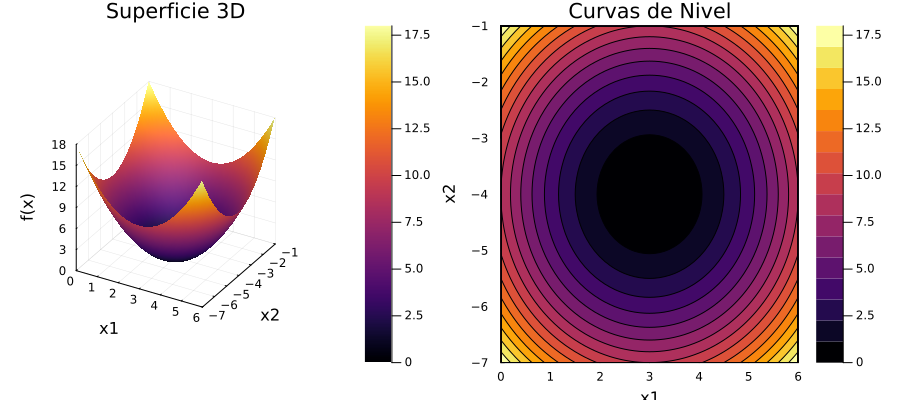

In [4]:
using Plots

f(x1, x2) = (x1 - 3)^2 + (x2 + 4)^2

x1_vals = 0:0.1:6
x2_vals = -7:0.1:-1

p1 = surface(x1_vals, x2_vals, f, 
             xlabel="x1", ylabel="x2", zlabel="f(x)", 
             title="Superficie 3D", camera=(30, 30))

p2 = contour(x1_vals, x2_vals, f, 
             xlabel="x1", ylabel="x2", 
             title="Curvas de Nivel", fill=true)

plot(p1, p2, layout=(1, 2), size=(900, 400))

## 2 exercise

Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [6]:
using Optim
using NLsolve

f(x) = (x[1] - 1)^4 + (x[2] - 2)^4

x0 = [0.0, 0.0]

result_optim = optimize(f, x0)

println("--- RESULTADO USANDO OPTIM.JL ---")
println("O mínimo encontrado foi no ponto: ", Optim.minimizer(result_optim))

function gradiente_fonc!(F, x)
    F[1] = 4 * (x[1] - 1)^3
    F[2] = 4 * (x[2] - 2)^3
end

result_nlsolve = nlsolve(gradiente_fonc!, x0)

println("\n--- RESULTADO USANDO NLSOLVE.JL (FONC) ---")
println("A raiz do gradiente (onde a inclinação é zero) é: ", result_nlsolve.zero)

--- RESULTADO USANDO OPTIM.JL ---
O mínimo encontrado foi no ponto: [0.9981447581936664, 1.9992588410321355]

--- RESULTADO USANDO NLSOLVE.JL (FONC) ---
A raiz do gradiente (onde a inclinação é zero) é: [0.9995401607802424, 1.9990803216092672]


## 3 exercise

Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

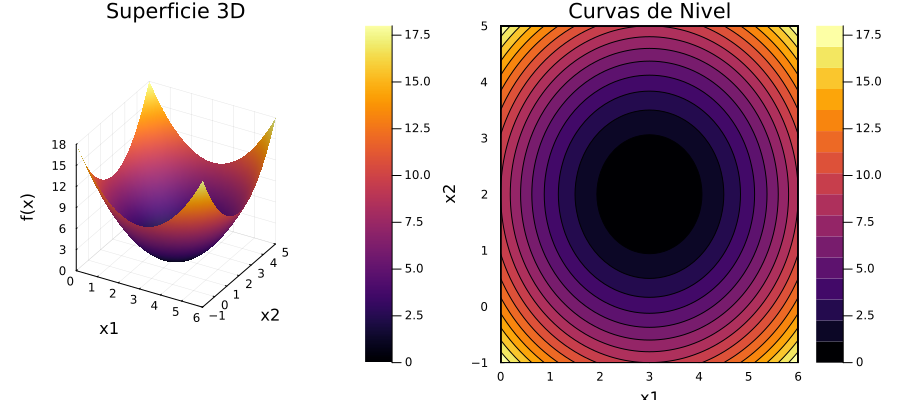

In [7]:
using Plots

f3(x1, x2) = (x1 - 3)^2 + (x2 - 2)^2

x1_vals = 0:0.1:6
x2_vals = -1:0.1:5

p_surf = surface(x1_vals, x2_vals, f3, 
                 xlabel="x1", ylabel="x2", zlabel="f(x)", 
                 title="Superficie 3D", camera=(30, 30))

p_cont = contour(x1_vals, x2_vals, f3, 
                 xlabel="x1", ylabel="x2", 
                 title="Curvas de Nivel", fill=true)

plot(p_surf, p_cont, layout=(1, 2), size=(900, 400))

## 4 exercise

Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

In [11]:
using LinearAlgebra

function gradient_descent(gradiente, x0, alpha, max_iter=1000, tol=1e-6)
    x = copy(x0)
    for i in 1:max_iter
        g = gradiente(x)
        if norm(g) < tol
            return x, i
        end
        x = x - alpha * g
    end
    return x, max_iter
end

function newton_method(gradiente, hessiana, x0, max_iter=100, tol=1e-6)
    x = copy(x0)
    for i in 1:max_iter
        g = gradiente(x)
        if norm(g) < tol
            return x, i
        end
        H = hessiana(x)
        passo = H \ g 
        x = x - passo
    end
    return x, max_iter
end

grad_f4(x) = [2*(x[1] - 3), 2*(x[2] - 2)]
hess_f4(x) = [2.0 0.0; 0.0 2.0]

x0 = [1.0, 1.0]

println("--- RESOLUÇÃO DA QUESTÃO 4 ---")
x_gd4, iter_gd4 = gradient_descent(grad_f4, x0, 0.1)
println("Gradiente Descendente -> Ponto: ", round.(x_gd4, digits=4), " | Iterações: ", iter_gd4)

x_nw4, iter_nw4 = newton_method(grad_f4, hess_f4, x0)
println("Método de Newton      -> Ponto: ", round.(x_nw4, digits=4), " | Iterações: ", iter_nw4)

--- RESOLUÇÃO DA QUESTÃO 4 ---
Gradiente Descendente -> Ponto: [3.0, 2.0] | Iterações: 70
Método de Newton      -> Ponto: [3.0, 2.0] | Iterações: 2


## 5 exercise

Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

In [12]:
grad_f5(x) = [20*(x[1] - 3), 4*(x[2] - 2)]
hess_f5(x) = [20.0 0.0; 0.0 4.0]

x_gd5, iter_gd5 = gradient_descent(grad_f5, x0, 0.04)
println("Gradiente Descendente -> Ponto: ", round.(x_gd5, digits=4), " | Iterações: ", iter_gd5)

x_nw5, iter_nw5 = newton_method(grad_f5, hess_f5, x0)
println("Método de Newton      -> Ponto: ", round.(x_nw5, digits=4), " | Iterações: ", iter_nw5)


--- RESOLUÇÃO DA QUESTÃO 5 ---
Gradiente Descendente -> Ponto: [3.0, 2.0] | Iterações: 89
Método de Newton      -> Ponto: [3.0, 2.0] | Iterações: 2


## 6 exercise

Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [13]:
grad_f6(x) = [2*x[1], 2*x[2]]
hess_f6(x) = [2.0 0.0; 0.0 2.0]
x0_6 = [-2.0, 2.0]

println("--- QUESTÃO 6 (Problema bem condicionado) ---")
x_gd6, iter_gd6 = gradient_descent(grad_f6, x0_6, 0.1)
x_nw6, iter_nw6 = newton_method(grad_f6, hess_f6, x0_6)

println("GD     -> Mínimo em: ", round.(x_gd6, digits=4), " | Iterações: ", iter_gd6)
println("Newton -> Mínimo em: ", round.(x_nw6, digits=4), " | Iterações: ", iter_nw6)

--- QUESTÃO 6 (Problema bem condicionado) ---
GD     -> Mínimo em: [-0.0, 0.0] | Iterações: 71
Newton -> Mínimo em: [0.0, 0.0] | Iterações: 2


## 7 exercise

Implement the same methods for the function $f(x) = x_1^2 + 100x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [14]:
grad_f7(x) = [2*x[1], 200*x[2]]
hess_f7(x) = [2.0 0.0; 0.0 200.0]
x0_7 = [-2.0, 2.0]

println("\n--- QUESTÃO 7 (Problema mal condicionado) ---")

x_gd7, iter_gd7 = gradient_descent(grad_f7, x0_7, 0.009) 
x_nw7, iter_nw7 = newton_method(grad_f7, hess_f7, x0_7)

println("GD     -> Mínimo em: ", round.(x_gd7, digits=4), " | Iterações: ", iter_gd7)
println("Newton -> Mínimo em: ", round.(x_nw7, digits=4), " | Iterações: ", iter_nw7)


--- QUESTÃO 7 (Problema mal condicionado) ---
GD     -> Mínimo em: [-0.0, -0.0] | Iterações: 838
Newton -> Mínimo em: [0.0, 0.0] | Iterações: 2


## 8 exercise

For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

In [15]:
grad_f8(x) = [2*x[1], 2*x[2]]
hess_f8(x) = [2.0 0.0; 0.0 2.0]
x0_8 = [-2.0, 20.0]

println("\n--- QUESTÃO 8 (Solução via Pré-condicionamento) ---")
x_gd8, iter_gd8 = gradient_descent(grad_f8, x0_8, 0.1)

x2_original = x_gd8[2] / 10.0

println("GD (Variáveis Novas) -> Mínimo (x1, y2): ", round.(x_gd8, digits=4), " | Iterações: ", iter_gd8)
println("Mínimo Original Recuperado (x1, x2): [", round(x_gd8[1], digits=4), ", ", round(x2_original, digits=4), "]")


--- QUESTÃO 8 (Solução via Pré-condicionamento) ---
GD (Variáveis Novas) -> Mínimo (x1, y2): [-0.0, 0.0] | Iterações: 80
Mínimo Original Recuperado (x1, x2): [-0.0, 0.0]


## 9 exercise

Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [18]:
using LinearAlgebra

function f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    
    term1 = x3 * log(exp(x1/x3) + exp(x2/x3))
    term2 = (x3 - 2)^2
    term3 = exp(1 / (x1 + x2))
    
    return term1 + term2 + term3
end

function grad_f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    
    exp_x1 = exp(x1/x3)
    exp_x2 = exp(x2/x3)
    sum_exp = exp_x1 + exp_x2
    exp_frac = exp(1 / (x1 + x2))
    den_sq = (x1 + x2)^2
    
    g1 = (exp_x1 / sum_exp) - (exp_frac / den_sq)
    g2 = (exp_x2 / sum_exp) - (exp_frac / den_sq)
    g3 = log(sum_exp) - (x1 * exp_x1 + x2 * exp_x2) / (x3 * sum_exp) + 2*(x3 - 2)
    
    return [g1, g2, g3]
end

function gradient_descent_backtracking(x0, max_iter=1000, tol=1e-5)
    x = copy(x0)
    c = 1e-4
    rho = 0.5
    
    for i in 1:max_iter
        g = grad_f(x)
        
        if norm(g) < tol
            return x, i
        end
        
        alpha = 1.0
        
        while true
            x_next = x - alpha * g
            
            if (x_next[1] + x_next[2] > 0) && (x_next[3] > 0)
                
                if f(x_next) <= f(x) - c * alpha * dot(g, g)
                    break
                end
            end
            
            alpha = alpha * rho
        end
        
        x = x - alpha * g
    end
    
    return x, max_iter
end

x0 = [1.0, 1.0, 1.0] 

x_opt, iters = gradient_descent_backtracking(x0)

println("Ponto de Mínimo Encontrado (x1, x2, x3): ", round.(x_opt, digits=4))
println("Quantidade de iterações necessárias: ", iters)
println("Valor da função nesse ponto mínimo: ", round(f(x_opt), digits=4))

Ponto de Mínimo Encontrado (x1, x2, x3): [0.9262, 0.9262, 1.6534]
Quantidade de iterações necessárias: 10
Valor da função nesse ponto mínimo: 3.9081


Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative 

In [2]:
function grad_f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    
    # Calculando partes repetidas para otimizar
    exp_x1 = exp(x1/x3)
    exp_x2 = exp(x2/x3)
    sum_exp = exp_x1 + exp_x2
    exp_frac = exp(1 / (x1 + x2))
    den_sq = (x1 + x2)^2
    
    # Derivadas conforme a fórmula
    g1 = (exp_x1 / sum_exp) - (exp_frac / den_sq)
    g2 = (exp_x2 / sum_exp) - (exp_frac / den_sq)
    g3 = log(sum_exp) - (x1 * exp_x1 + x2 * exp_x2) / (x3 * sum_exp) + 2*(x3 - 2)
    
    return [g1, g2, g3]
end

grad_f (generic function with 1 method)

Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [7]:
using LinearAlgebra

function f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    return x3 * log(exp(x1/x3) + exp(x2/x3)) + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

alpha_armijo = 0.4  # Tolerância de descida da função
beta = 0.5          # Fator de corte do passo
tol = 1e-5          # Tolerância de parada
x0 = [3.0, 4.0, 5.0] # Ponto inicial

function gradient_descent_boyd(x0, alpha, beta, tol, max_iter=1000)
    x = copy(x0)
    
    for iter in 1:max_iter
        g = grad_f(x)
        dx = -g
        
        if norm(g) < tol
            return x, iter
        end
        
        t = 1.0 # Set t := 1
        
        while ((x + t*dx)[1] + (x + t*dx)[2] <= 0) || ((x + t*dx)[3] <= 0)
            t = beta * t
        end
        
        while f(x + t*dx) > f(x) + alpha * t * dot(g, dx)
            t = beta * t
        end
        
        x = x + t * dx
    end
    
    return x, max_iter
end

x_opt, iteracoes = gradient_descent_boyd(x0, alpha_armijo, beta, tol)

println("Mínimo encontrado em (x1, x2, x3): ", round.(x_opt, digits=5))
println("Total de iterações: ", iteracoes)
println("Valor da função no mínimo: ", round(f(x_opt), digits=5))

--- EXECUTANDO O ALGORITMO COM OS PARÂMETROS DO PROFESSOR ---
Mínimo encontrado em (x1, x2, x3): [0.92619, 0.92623, 1.65343]
Total de iterações: 31
Valor da função no mínimo: 3.90811


Start Point: [3.0, 4.0, 5.0]

In [10]:
using LinearAlgebra

function f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    return x3 * log(exp(x1/x3) + exp(x2/x3)) + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

function grad_f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    
    exp_x1 = exp(x1/x3)
    exp_x2 = exp(x2/x3)
    sum_exp = exp_x1 + exp_x2
    exp_frac = exp(1 / (x1 + x2))
    den_sq = (x1 + x2)^2
    
    g1 = (exp_x1 / sum_exp) - (exp_frac / den_sq)
    g2 = (exp_x2 / sum_exp) - (exp_frac / den_sq)
    g3 = log(sum_exp) - (x1 * exp_x1 + x2 * exp_x2) / (x3 * sum_exp) + 2*(x3 - 2)
    
    return [g1, g2, g3]
end

function hessian_approx(x, h=1e-5)
    n = length(x)
    H = zeros(n, n)
    g_x = grad_f(x)
    
    for i in 1:n
        x_step = copy(x)
        x_step[i] += h
        g_step = grad_f(x_step)
        H[:, i] = (g_step - g_x) / h
    end
    
    return (H + H') / 2.0
end

x0 = [3.0, 4.0, 5.0]
alpha_armijo = 0.4
beta = 0.5
tol = 1e-5

function newton_method_backtracking(x0, alpha, beta, tol, max_iter=100)
    x = copy(x0)
    
    for iter in 1:max_iter
        g = grad_f(x)
        
        if norm(g) < tol
            return x, iter
        end
        
        H = hessian_approx(x)
        
        dx = H \ (-g)
        
        t = 1.0 
        
        while ((x + t*dx)[1] + (x + t*dx)[2] <= 0) || ((x + t*dx)[3] <= 0)
            t = beta * t
        end
        
        while f(x + t*dx) > f(x) + alpha * t * dot(g, dx)
            t = beta * t
        end
        
        x = x + t * dx
    end
    
    return x, max_iter
end

println("--- RESOLUÇÃO COM O MÉTODO DE NEWTON ---")
x_opt_nw, iteracoes_nw = newton_method_backtracking(x0, alpha_armijo, beta, tol)

println("Mínimo encontrado em (x1, x2, x3): ", round.(x_opt_nw, digits=5))
println("Total de iterações: ", iteracoes_nw)
println("Valor da função no mínimo: ", round(f(x_opt_nw), digits=5))

--- RESOLUÇÃO COM O MÉTODO DE NEWTON ---
Mínimo encontrado em (x1, x2, x3): [0.92621, 0.92621, 1.65343]
Total de iterações: 6
Valor da função no mínimo: 3.90811


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

In [19]:
using LinearAlgebra

function f(x)
    x1, x2, x3 = x[1], x[2], x[3]
    return x3 * log(exp(x1/x3) + exp(x2/x3)) + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

alpha_armijo = 0.4  # Tolerância de descida da função
beta = 0.5          # Fator de corte do passo
tol = 1e-5          # Tolerância de parada
x0 = [3.0, 4.0, 5.0] # Ponto inicial

# 3. O Algoritmo de Gradiente com Backtracking
function gradient_descent_boyd(x0, alpha, beta, tol, max_iter=1000)
    x = copy(x0)
    
    for iter in 1:max_iter
        g = grad_f(x)
        dx = -g
        
        if norm(g) < tol
            return x, iter
        end
        
        t = 1.0 # Set t := 1
        
        while ((x + t*dx)[1] + (x + t*dx)[2] <= 0) || ((x + t*dx)[3] <= 0)
            t = beta * t
        end
        
        while f(x + t*dx) > f(x) + alpha * t * dot(g, dx)
            t = beta * t
        end
        
        x = x + t * dx
    end
    
    return x, max_iter
end

x_opt, iteracoes = gradient_descent_boyd(x0, alpha_armijo, beta, tol)

println("Mínimo encontrado em (x1, x2, x3): ", round.(x_opt, digits=5))
println("Total de iterações: ", iteracoes)
println("Valor da função no mínimo: ", round(f(x_opt), digits=5))

Mínimo encontrado em (x1, x2, x3): [0.92619, 0.92623, 1.65343]
Total de iterações: 31
Valor da função no mínimo: 3.90811


## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [20]:
function hessian_approx(x, h=1e-5)
    n = length(x)
    H = zeros(n, n)
    
    g_x = grad_f(x)
    
    for i in 1:n
        x_step = copy(x)
        x_step[i] += h
        
        g_step = grad_f(x_step)
        
        H[:, i] = (g_step - g_x) / h
    end

    return (H + H') / 2.0
end

x_teste = [3.0, 4.0, 5.0]
H_teste = hessian_approx(x_teste)

println("Matriz Hessiana no ponto inicial:")
display(round.(H_teste, digits=4))

Matriz Hessiana no ponto inicial:


3×3 Matrix{Float64}:
  0.0567  -0.0423   0.0099
 -0.0423   0.0567  -0.0099
  0.0099  -0.0099   2.002

Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [21]:
# Definindo os parâmetros para o Backtracking e o Ponto Inicial
alpha_armijo = 0.4  # Ele chamou de alpha no texto
beta = 0.5          # Fator de redução do passo
tol = 1e-5          # Tolerância de parada (eps)
x0 = [3.0, 4.0, 5.0] # Ponto de partida (Start Point)

println("Parâmetros do Método de Newton carregados com sucesso!")

Parâmetros do Método de Newton carregados com sucesso!


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


# code

### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

In [14]:
using LinearAlgebra

function newton_method_boyd(x0, alpha, beta, tol, max_iter=100)
    x = copy(x0)
    
    for iter in 1:max_iter
        g = grad_f(x)
        H = hessian_approx(x)
        
        #Calcula a direção (dx)
        dx = H \ (-g)

        lambda_sq = -dot(g, dx)
        
        if lambda_sq / 2.0 <= tol
            return x, iter
        end
        
        t = 1.0 
        
        while ((x + t*dx)[1] + (x + t*dx)[2] <= 0) || ((x + t*dx)[3] <= 0)
            t = beta * t
        end
        
        while f(x + t*dx) > f(x) + alpha * t * dot(g, dx)
            t = beta * t
        end
        
        x = x + t * dx
    end
    
    return x, max_iter
end

println("--- RESOLUÇÃO COM O MÉTODO DE NEWTON (CRITÉRIO DE DECREMENTO) ---")
x_opt_boyd, iteracoes_boyd = newton_method_boyd(x0, alpha_armijo, beta, tol)

println("Mínimo encontrado em (x1, x2, x3): ", round.(x_opt_boyd, digits=5))
println("Total de iterações: ", iteracoes_boyd)
println("Valor da função no mínimo: ", round(f(x_opt_boyd), digits=5))

--- RESOLUÇÃO COM O MÉTODO DE NEWTON (CRITÉRIO DE DECREMENTO) ---
Mínimo encontrado em (x1, x2, x3): [0.92598, 0.926, 1.6533]
Total de iterações: 5
Valor da função no mínimo: 3.90811


## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ 

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [22]:

alpha_armijo = 0.4
beta = 0.5
tol = 1e-5
x0 = [3.0, 4.0, 5.0]

function backtracking_line_search(x, dx, g, alpha, beta)
    t = 1.0
    
    while ((x + t*dx)[1] + (x + t*dx)[2] <= 0) || ((x + t*dx)[3] <= 0)
        t = beta * t
    end
    
    while f(x + t*dx) > f(x) + alpha * t * dot(g, dx)
        t = beta * t
    end
    
    return t
end

println("Parâmetros e função de Backtracking modular carregados com sucesso!")

Parâmetros e função de Backtracking modular carregados com sucesso!


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


### Running the BFGS Algorithm: 

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


In [23]:
using LinearAlgebra

function bfgs_method(x0, alpha, beta, tol, max_iter=1000)
    x = copy(x0)
    n = length(x)
    
    H = Matrix{Float64}(I, n, n) 
    
    for iter in 1:max_iter
        g = grad_f(x)
        
        if norm(g) < tol
            return x, iter
        end
        
        p = -H * g
        
        t = backtracking_line_search(x, p, g, alpha, beta)
        x_next = x + t * p
        
        s = x_next - x
        g_next = grad_f(x_next)
        y = g_next - g
        
        y_dot_s = dot(y, s)
        
        if y_dot_s < 1e-4
            rho = 1e4
        else
            rho = 1.0 / y_dot_s
        end
        
        I_mat = Matrix{Float64}(I, n, n)
        
        term1 = I_mat - rho * (s * y')
        term2 = I_mat - rho * (y * s')
        
        H = term1 * H * term2 + rho * (s * s')
        
        x = x_next
    end
    
    return x, max_iter
end

x_opt_bfgs, iteracoes_bfgs = bfgs_method(x0, alpha_armijo, beta, tol)

println("Mínimo encontrado em (x1, x2, x3): ", round.(x_opt_bfgs, digits=5))
println("Total de iterações: ", iteracoes_bfgs)
println("Valor da função no mínimo: ", round(f(x_opt_bfgs), digits=5))

Mínimo encontrado em (x1, x2, x3): [0.92621, 0.92621, 1.65343]
Total de iterações: 13
Valor da função no mínimo: 3.90811


# Problem Statement: Optimal Control for CSTR

We are given the liearized discrete state space model, time horizon, initial state, setpoints for controlled variables, and variable bounds 

#### Defining state space model, time horizon, initial state, and variable bounds

Note: since it is assumed that all the states are measurable without noise, here the controlled variables are represented using x instead for simplicity

Hints: use matrix A, B from material. Time horizon = 3; Initial condition: [-0.03, 0.0, 0.3]; bounds: xmax = [0.05, 5, 0.5]; xmin = [-0.05, -5, -0.5]; umax = [10, 0.05]; umin = [-10, -0.05]

## Model

The LP model for the problem can be derived as follows:


\begin{aligned}
\min_{u(0),u(1),u(2)} \quad &\sum_{k=0}^{k=3} (z_1(k)+z_2(k)) \\
\textit{s.t.} \quad &{x}(k+1) ={A} {x}(k)+{B u}(k) \quad k=0,1,2 \\
&y(k) ={C} {x}(k) \quad k=0,1,2,3 \\
&{x}(0) = \begin{bmatrix}
-0.03 \\
0 \\
0.3
\end{bmatrix} \\
&\begin{bmatrix}
-0.05 \\
-5 \\
-0.5
\end{bmatrix} 
\leq x(k) \leq 
\begin{bmatrix}
0.05 \\
5 \\
0.5
\end{bmatrix} \quad k=0,1,2,3 \\
&\begin{bmatrix}
-10 \\
-0.05
\end{bmatrix} 
\leq u(k) \leq 
\begin{bmatrix}
10 \\
0.05
\end{bmatrix} \quad k=0,1,2 \\
&-z_1(k) \leq y_1(k) \leq z_1(k) \quad k=0,1,2,3 \\
&-z_2(k) \leq y_3(k) \leq z_2(k) \quad k=0,1,2,3 \\
\end{aligned}



## Implement

In [2]:
using JuMP
using HiGHS
using LinearAlgebra

#PARÂMETROS REAIS DO CSTR (Extraídos do T02.pdf)

T = 3
x0 = [-0.03, 0.0, 0.3]

A = [0.2681 -0.00338 -0.00728;
     9.703   0.3279   -25.44;
     0.0     0.0       1.0]

B = [-0.00537  0.1655;
      1.297    97.91;
      0.0     -6.637]

x_min = [-0.05, -5.0, -0.5]
x_max = [0.05, 5.0, 0.5]
u_min = [-10.0, -0.05]
u_max = [10.0, 0.05]

#CONSTRUÇÃO DO MODELO LP

model = Model(HiGHS.Optimizer)
set_silent(model)

# Variáveis
@variable(model, x_min[i] <= x[i=1:3, k=0:T] <= x_max[i])
@variable(model, u_min[j] <= u[j=1:2, k=0:T-1] <= u_max[j])
@variable(model, z1[k=0:T])
@variable(model, z2[k=0:T])

# Restrições
@constraint(model, x[:, 0] .== x0)

# Dinâmica do Reator: x(k+1) = Ax(k) + Bu(k)
for k in 0:(T-1)
    @constraint(model, x[:, k+1] .== A * x[:, k] + B * u[:, k])
end

# 3. Linearização do Valor Absoluto
for k in 0:T
    @constraint(model, z1[k] >= x[1, k])
    @constraint(model, z1[k] >= -x[1, k])
    
    @constraint(model, z2[k] >= x[3, k])
    @constraint(model, z2[k] >= -x[3, k])
end

@objective(model, Min, sum(z1[k] + z2[k] for k in 0:T))

#RESULTADOS

optimize!(model)

if termination_status(model) == OPTIMAL
    println("SOLUÇÃO ENCONTRADA!")
    println("Custo Total Mínimo: ", round(objective_value(model), digits=4))
    
    println("\nTrajetória de Controle (u):")
    for k in 0:T-1
        val_u = value.(u[:, k])
        println("k=$k -> u1 (Vazão): ", round(val_u[1], digits=4), " | u2 (Temp): ", round(val_u[2], digits=4))
    end
    
    println("\nEstados do Reator (x):")
    for k in 0:T
        val_x = value.(x[:, k])
        println("k=$k -> x1 (Conc): ", round(val_x[1], digits=4), " | x2: ", round(val_x[2], digits=4), " | x3 (Nível): ", round(val_x[3], digits=4))
    end
else
    println("Erro: O solver não encontrou solução ótima.")
end

SOLUÇÃO ENCONTRADA!
Custo Total Mínimo: 0.33

Trajetória de Controle (u):
k=0 -> u1 (Vazão): -0.5114 | u2 (Temp): 0.0452
k=1 -> u1 (Vazão): 2.6189 | u2 (Temp): -0.0
k=2 -> u1 (Vazão): -1.2792 | u2 (Temp): -0.0

Estados do Reator (x):
k=0 -> x1 (Conc): -0.03 | x2: -0.0 | x3 (Nível): 0.3
k=1 -> x1 (Conc): -0.0 | x2: -4.1607 | x3 (Nível): -0.0
k=2 -> x1 (Conc): -0.0 | x2: 2.0324 | x3 (Nível): -0.0
k=3 -> x1 (Conc): -0.0 | x2: -0.9927 | x3 (Nível): -0.0


## Solve and Postprocess

In [ ]:
# code and plot some graphics

# plot controlled variables and input variables